In [56]:
import numpy as np
import pandas as pd
import re
import geopandas as gpd
from haversine import haversine, Unit
from sklearn.preprocessing import MinMaxScaler

# 1. 바나프레소 정보만 가져오기

1. 서울 카페 정보 중 **바나프레소** 인 것만 필터링.
2. apv_date가 3년 전 이상인 것만 필터링 why? 3년 이상 영업 가게를 성공 가게라고 판단했기 때문.

In [35]:
# 카페 데이터 가져오기
cafe = pd.read_csv("C:/vs_code_prj/brewmap/data/mj/cafe.csv")
cafe.head()

,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,adstrd_cd
0,베레베레,커피숍,2002-09-19,서울 광진구 능동로13길 19,NaN,NaN,37.542885,127.070832,T,3120053.0,11215710
1,덕수궁전통차전문,커피숍,2003-01-16,서울 중구 서소문로 109,2.0,46.28,37.563062,126.973280,T,3120020.0,11140520
2,엘빠소,커피숍,2003-05-31,서울 종로구 성균관로 18,NaN,NaN,37.584406,126.997641,T,3110021.0,11110650
3,씨애틀즈베스트커피대사관점,커피숍,2003-10-31,서울 종로구 세종대로 188,1.0,NaN,37.573190,126.977831,A,NaN,11110615
4,본솔카페,커피숍,2004-01-17,서울 용산구 청파로47길 71,1.0,13.80,37.544840,126.966455,T,3110069.0,11170555


In [60]:
# 바나프레소만 추출
bana_df = cafe[cafe['nm'].str.contains(r"바나프레소|banapresso", case=False, na=False)].copy()
print(len(bana_df))

# 날짜 변환
bana_df['apv_date'] = pd.to_datetime(bana_df['apv_date'], errors='coerce')

# 오늘 기준 3년 이상(= 3년 전 이하) 된 매장만
cutoff = pd.Timestamp.today().normalize() - pd.DateOffset(years=3)
bana_df["success"] = (bana_df["apv_date"] <= cutoff).astype(int)

# 확인
bana_df["success"].value_counts()

59


success
0    49
1    10
Name: count, dtype: int64

# 2. 수요 점수 변수
2024년 4분기부터 2025년 3분기 까지의 데이터 사용 
<br>
- 2-1. 유동 인구_점심: tmzon_11_14_flpop_co
- 2-2. 유동 인구_저녁: tmzon_17_21_flpop_co
- 2-3. 유동 인구_기타 시간 평균: tmzon_00_06_flpop_co, tmzon_06_11_flpop_co, tmzon_14_17_flpop_co, tmzon_21_24_flpop_co

In [61]:
print(bana_df["flpop_type"].unique())

<StringArray>
['T', 'A']
Length: 2, dtype: str


- 성공한 카페는 flpop_t.csv 만으로도 유동인구 값 가져올 수 있음

In [62]:
# 유동인구 데이터 불러오기
flpop_t = pd.read_csv("C:/vs_code_prj/brewmap/data/mj/flpop_t.csv")
flpop_a = pd.read_csv("C:/vs_code_prj/brewmap/data/mj/flpop_a.csv")
print(flpop_t.columns)
print(flpop_a.columns)

Index(['stdr_yyqu_cd', 'trdar_se_cd_nm', 'trdar_cd', 'trdar_cd_nm',
       'tot_flpop_co', 'ml_flpop_co', 'fml_flpop_co', 'agrde_10_flpop_co',
       'agrde_20_flpop_co', 'agrde_30_flpop_co', 'agrde_40_flpop_co',
       'agrde_50_flpop_co', 'agrde_60_above_flpop_co', 'tmzon_00_06_flpop_co',
       'tmzon_06_11_flpop_co', 'tmzon_11_14_flpop_co', 'tmzon_14_17_flpop_co',
       'tmzon_17_21_flpop_co', 'tmzon_21_24_flpop_co', 'mon_flpop_co',
       'tues_flpop_co', 'wed_flpop_co', 'thur_flpop_co', 'fri_flpop_co',
       'sat_flpop_co', 'sun_flpop_co'],
      dtype='str')
Index(['stdr_yyqu_cd', 'adstrd_cd', 'adstrd_cd_nm', 'tot_flpop_co',
       'ml_flpop_co', 'fml_flpop_co', 'agrde_10_flpop_co', 'agrde_20_flpop_co',
       'agrde_30_flpop_co', 'agrde_40_flpop_co', 'agrde_50_flpop_co',
       'agrde_60_above_flpop_co', 'tmzon_00_06_flpop_co',
       'tmzon_06_11_flpop_co', 'tmzon_11_14_flpop_co', 'tmzon_14_17_flpop_co',
       'tmzon_17_21_flpop_co', 'tmzon_21_24_flpop_co', 'mon_flpop_co',


In [63]:
# 최근 4개 분기 추출
recent_quarters = sorted(flpop_t["stdr_yyqu_cd"].unique())[-4:]

# 필터링
flpop_t = flpop_t[flpop_t["stdr_yyqu_cd"].isin(recent_quarters)]
flpop_a = flpop_a[flpop_a["stdr_yyqu_cd"].isin(recent_quarters)]

In [64]:
# 중복(이상치) 확인
print(flpop_t[["stdr_yyqu_cd","trdar_cd"]].duplicated().sum())
print(flpop_a[["stdr_yyqu_cd","adstrd_cd"]].duplicated().sum())

0
0


In [65]:
# 분기 평균 집계
agg_cols = ["tmzon_11_14_flpop_co", "tmzon_17_21_flpop_co",
            "tmzon_00_06_flpop_co", "tmzon_06_11_flpop_co",
            "tmzon_14_17_flpop_co", "tmzon_21_24_flpop_co"]

flpop_t_agg = flpop_t.groupby("trdar_cd")[agg_cols].mean().reset_index()
flpop_a_agg = flpop_a.groupby("adstrd_cd")[agg_cols].mean().reset_index()

# etc 평균 계산
etc_cols = ["tmzon_00_06_flpop_co", "tmzon_06_11_flpop_co", "tmzon_14_17_flpop_co", "tmzon_21_24_flpop_co"]
flpop_t_agg["flpop_etc"] = flpop_t_agg[etc_cols].mean(axis=1)
flpop_a_agg["flpop_etc"] = flpop_a_agg[etc_cols].mean(axis=1)

In [66]:
flpop_a_agg

,adstrd_cd,tmzon_11_14_flpop_co,tmzon_17_21_flpop_co,tmzon_00_06_flpop_co,tmzon_06_11_flpop_co,tmzon_14_17_flpop_co,tmzon_21_24_flpop_co,flpop_etc
0,11110515,500612.50,578186.75,764008.75,695880.25,496522.75,396395.75,5.882019e+05
1,11110530,785096.00,800972.75,462503.75,833639.75,795807.75,329475.00,6.053566e+05
2,11110540,189512.25,162304.25,158158.75,197656.50,187852.75,80772.75,1.561102e+05
3,11110550,113146.00,138369.00,233406.50,193447.25,109598.75,114718.50,1.627928e+05
4,11110560,95763.00,138732.75,263526.50,190671.50,94246.75,123374.00,1.679547e+05
...,...,...,...,...,...,...,...,...
420,11740650,920444.50,1377540.25,2302846.00,1689404.25,935937.50,1107762.25,1.508988e+06
421,11740660,762420.50,1072372.75,1852932.25,1368657.50,746946.00,885058.75,1.213399e+06
422,11740685,2099678.75,2972146.50,4900869.50,3691237.75,2090460.00,2401415.00,3.270996e+06
423,11740690,2754.75,3662.25,6182.75,4974.50,2686.75,2983.00,4.206750e+03


In [67]:
# flpop_type T 매핑
tr_mask = bana_df["flpop_type"] == "T"
tr_merged = bana_df[tr_mask].merge(
    flpop_t_agg[["trdar_cd", "tmzon_11_14_flpop_co", "tmzon_17_21_flpop_co", "flpop_etc"]],
    on="trdar_cd", how="left"
)

# flpop_type A 매핑
ad_mask = bana_df["flpop_type"] == "A"
ad_merged = bana_df[ad_mask].merge(
    flpop_a_agg[["adstrd_cd", "tmzon_11_14_flpop_co", "tmzon_17_21_flpop_co", "flpop_etc"]],
    on="adstrd_cd", how="left"
)

# 합치기 & 컬럼명 정리
bana_df = pd.concat([tr_merged, ad_merged]).sort_index().rename(columns={
    "tmzon_11_14_flpop_co": "flpop_lunch",
    "tmzon_17_21_flpop_co": "flpop_dinner"
})

print(bana_df.shape)
bana_df.head()

(59, 16)


,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,adstrd_cd,detail,success,flpop_lunch,flpop_dinner,flpop_etc
0,바나프레소 테헤란로점,커피숍,2019-05-23,서울 강남구 테헤란로 208,1.0,98.40,37.501130,127.039099,T,3120197.0,11680650,banapresso,1,985131.50,882135.00,752222.8125
0,바나프레소 중계은행사거리점,커피숍,2023-03-24,서울 노원구 덕릉로76길 18,1.0,28.70,37.654291,127.075304,A,NaN,11350621,banapresso,0,418872.50,654206.75,676400.0625
1,banapresso 위례중앙점,커피숍,2023-05-01,서울 송파구 위례광장로 120,1.0,40.10,37.475010,127.141593,A,NaN,11710647,banapresso,0,353384.75,554050.25,582902.9375
1,바나프레소 신논현역점,커피숍,2019-08-06,서울 서초구 사평대로 364,1.0,107.24,37.503733,127.023196,T,3120187.0,11650531,banapresso,1,589152.00,788268.00,560948.1250
2,바나프레소 선릉공원점,커피숍,2021-07-23,서울 강남구 테헤란로63길 20,1.0,97.28,37.506522,127.050398,T,3120210.0,11680590,banapresso,1,951358.25,983513.00,833761.1250


In [68]:
len(bana_df)

59

    2-4. 학교 수
    2-5. 지식산업센터 수
    2-6. 병원 수 
    2-7. 학원 수
    2-8. 체육도장업 수 

In [69]:
academy = pd.read_csv("C:/vs_code_prj/brewmap/data/sa/seoul_data/academy_df.csv")
gym = pd.read_csv("C:/vs_code_prj/brewmap/data/sa/seoul_data/gym_df.csv")
hospital = pd.read_csv("C:/vs_code_prj/brewmap/data/sa/seoul_data/hospital_df.csv")
physical = pd.read_csv("C:/vs_code_prj/brewmap/data/sa/seoul_data/physical_df.csv")
school = pd.read_csv("C:/vs_code_prj/brewmap/data/sa/seoul_data/school.csv")
center = pd.read_csv("C:/vs_code_prj/brewmap/data/mj/industry_center.csv")
print(academy.columns)
print(gym.columns)
print(hospital.columns)
print(physical.columns)
print(school.columns)
print(center.columns)

Index(['idx', 'nm', 'addr', 'lat', 'lng'], dtype='str')
Index(['idx', 'dtlstatenm', 'addr', 'nm', 'type', 'lat', 'lng'], dtype='str')
Index(['idx', 'dtlstatenm', 'nm', 'type', 'addr', 'lat', 'lng'], dtype='str')
Index(['idx', 'dtlstatenm', 'addr', 'type', 'nm', 'lat', 'lng'], dtype='str')
Index(['idx', 'nm', 'addr', 'type', 'lat', 'lng'], dtype='str')
Index(['nm', 'type', 'addr', 'lat', 'lng'], dtype='str')


In [70]:
# academy 에 type 칼럼이 없어서 추가
academy['type'] = '학원'
academy.head()

,idx,nm,addr,lat,lng,type
0,1,클릭전원미술학원,서울특별시 마포구 와우산로 138 (창전동),37.553572,126.928993,학원
1,2,고려직업전문학교,서울특별시 동작구 노량진로 186 (노량진동),37.512575,126.946031,학원
2,3,노량진행정고시학원,서울특별시 동작구 노량진로 171 (노량진동),37.514034,126.945198,학원
3,4,박문각임용고시학원,서울특별시 동작구 노량진로 171 (노량진동),37.514034,126.945198,학원
4,5,노량진메가스터디입시어학원,서울특별시 동작구 장승배기로 171 (노량진동),37.513017,126.939945,학원


In [71]:
# 하나의 데이터프레임으로 만들기
dfs = [academy, gym, hospital, physical, school, center]

need_cols = ["type", "nm", "addr", "lat", "lng"]

# 각 df에서 필요한 컬럼만 추출(없는 컬럼은 NaN으로 생성)
picked = [d.reindex(columns=need_cols) for d in dfs]

# 세로로 합치기
buildings_df = pd.concat(picked, ignore_index=True)

buildings_df.head()

,type,nm,addr,lat,lng
0,학원,클릭전원미술학원,서울특별시 마포구 와우산로 138 (창전동),37.553572,126.928993
1,학원,고려직업전문학교,서울특별시 동작구 노량진로 186 (노량진동),37.512575,126.946031
2,학원,노량진행정고시학원,서울특별시 동작구 노량진로 171 (노량진동),37.514034,126.945198
3,학원,박문각임용고시학원,서울특별시 동작구 노량진로 171 (노량진동),37.514034,126.945198
4,학원,노량진메가스터디입시어학원,서울특별시 동작구 장승배기로 171 (노량진동),37.513017,126.939945


In [72]:
buildings_df['type'].unique()

<StringArray>
['학원', '병원', '학교', '지식산업센터']
Length: 4, dtype: str

In [73]:
# 반경 300m 안 개수 찾기

# 0) type 매핑
type_map = {
    "학원": "cnt_academy",
    "병원": "cnt_hospital",
    "학교": "cnt_school",
    "지식산업센터": "cnt_company"
}

# 1) 함수 정의
def count_buildings_nearby(cafe_lat, cafe_lon, buildings_df, radius=300):
    mask = buildings_df.apply(
        lambda row: haversine(
            (cafe_lat, cafe_lon), (row["lat"], row["lng"]), unit=Unit.METERS
        ) <= radius, axis=1
    )
    nearby = buildings_df[mask]
    counts = nearby.groupby("type").size()
    
    # 없는 type도 0으로 채우기
    counts = counts.reindex(type_map.keys(), fill_value=0)
    
    # 영어로 rename
    counts.index = [type_map[t] for t in counts.index]
    return counts

# 적용
result = bana_df.apply(
    lambda row: count_buildings_nearby(row["lat"], row["lng"], buildings_df),
    axis=1
).fillna(0).astype(int)

bana_df = pd.concat([bana_df, result], axis=1)
bana_df.head()

,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,adstrd_cd,detail,success,flpop_lunch,flpop_dinner,flpop_etc,cnt_academy,cnt_hospital,cnt_school,cnt_company
0,바나프레소 테헤란로점,커피숍,2019-05-23,서울 강남구 테헤란로 208,1.0,98.40,37.501130,127.039099,T,3120197.0,11680650,banapresso,1,985131.50,882135.00,752222.8125,0,1,0,0
0,바나프레소 중계은행사거리점,커피숍,2023-03-24,서울 노원구 덕릉로76길 18,1.0,28.70,37.654291,127.075304,A,NaN,11350621,banapresso,0,418872.50,654206.75,676400.0625,0,0,0,0
1,banapresso 위례중앙점,커피숍,2023-05-01,서울 송파구 위례광장로 120,1.0,40.10,37.475010,127.141593,A,NaN,11710647,banapresso,0,353384.75,554050.25,582902.9375,0,0,0,0
1,바나프레소 신논현역점,커피숍,2019-08-06,서울 서초구 사평대로 364,1.0,107.24,37.503733,127.023196,T,3120187.0,11650531,banapresso,1,589152.00,788268.00,560948.1250,0,1,0,0
2,바나프레소 선릉공원점,커피숍,2021-07-23,서울 강남구 테헤란로63길 20,1.0,97.28,37.506522,127.050398,T,3120210.0,11680590,banapresso,1,951358.25,983513.00,833761.1250,1,2,0,0


# 3. 접근성 점수 변수
    3-1. 지하철역 최소 거리
    3-2. 버스정류장 최소 거리
    3-3. 대로변 여부
    3-4. 횡단보도 수

In [74]:
bus_stop = pd.read_csv("C:/vs_code_prj/brewmap/data/dh/bus_stop.csv")
station = pd.read_csv("C:/vs_code_prj/brewmap/data/dh/station.csv")
crosswalk = pd.read_csv("C:/vs_code_prj/brewmap/data/dh/crosswalk.csv")
road = pd.read_csv("C:/vs_code_prj/brewmap/data/dh/road.csv")

print(bus_stop.columns)
print(station.columns)
print(crosswalk.columns)
print(road.columns)

Index(['bus_stop_id', 'bus_stop_nm', 'lng', 'lat', 'type'], dtype='str')
Index(['addr', 'type', 'lat', 'lng'], dtype='str')
Index(['lng', 'lat', 'sigungu', 'emd', 'type'], dtype='str')
Index(['road_address', 'lng', 'lat', 'type'], dtype='str')


In [75]:
# 최소 거리
def min_distance(cafe_lat, cafe_lon, df):
    distances = df.apply(
        lambda row: haversine(
            (cafe_lat, cafe_lon), (row["lat"], row["lng"]), unit=Unit.METERS
        ), axis=1
    )
    return distances.min()

# 300m 안 횡단보도 개수
def count_within(cafe_lat, cafe_lon, df, radius=300):
    mask = df.apply(
        lambda row: haversine(
            (cafe_lat, cafe_lon), (row["lat"], row["lng"]), unit=Unit.METERS
        ) <= radius, axis=1
    )
    return mask.sum()

# 300m 안 대로변 여부
def is_roadside(cafe_lat, cafe_lon, df, radius=300):
    mask = df.apply(
        lambda row: haversine(
            (cafe_lat, cafe_lon), (row["lat"], row["lng"]), unit=Unit.METERS
        ) <= radius, axis=1
    )
    return int(mask.any())  # 1개라도 있으면 1, 없으면 0

# bana_old_df에 적용
bana_df["dist_station"]    = bana_df.apply(lambda row: min_distance(row["lat"], row["lng"], station), axis=1)
bana_df["dist_bus_stop"]   = bana_df.apply(lambda row: min_distance(row["lat"], row["lng"], bus_stop), axis=1)
bana_df["cnt_crosswalk"] = bana_df.apply(lambda row: count_within(row["lat"], row["lng"], crosswalk), axis=1)
bana_df["is_road"]     = bana_df.apply(lambda row: is_roadside(row["lat"], row["lng"], road), axis=1)
bana_df

,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,...,flpop_dinner,flpop_etc,cnt_academy,cnt_hospital,cnt_school,cnt_company,dist_station,dist_bus_stop,cnt_crosswalk,is_road
0,바나프레소 테헤란로점,커피숍,2019-05-23,서울 강남구 테헤란로 208,1.0,98.40,37.501130,127.039099,T,3120197.0,...,882135.00,7.522228e+05,0,1,0,0,223.598018,24.766102,8,1
0,바나프레소 중계은행사거리점,커피숍,2023-03-24,서울 노원구 덕릉로76길 18,1.0,28.70,37.654291,127.075304,A,NaN,...,654206.75,6.764001e+05,0,0,0,0,750.922345,116.274918,18,1
1,banapresso 위례중앙점,커피숍,2023-05-01,서울 송파구 위례광장로 120,1.0,40.10,37.475010,127.141593,A,NaN,...,554050.25,5.829029e+05,0,0,0,0,1379.887436,72.955206,23,1
1,바나프레소 신논현역점,커피숍,2019-08-06,서울 서초구 사평대로 364,1.0,107.24,37.503733,127.023196,T,3120187.0,...,788268.00,5.609481e+05,0,1,0,0,765.979395,57.031538,18,1
2,바나프레소 선릉공원점,커피숍,2021-07-23,서울 강남구 테헤란로63길 20,1.0,97.28,37.506522,127.050398,T,3120210.0,...,983513.00,8.337611e+05,1,2,0,0,258.610257,139.653177,16,1
2,바나프레소 고덕비즈밸리점,커피숍,2025-03-25,서울 강동구 고덕비즈밸리로2가길 50,1.0,55.84,37.567589,127.159990,A,NaN,...,342827.25,3.808215e+05,0,0,0,0,1319.329872,66.847849,6,1
3,바나프레소 서울시청역점,커피숍,2025-05-14,서울 중구 서소문로 89-20,-1.0,36.68,37.563251,126.972031,A,NaN,...,482929.25,3.823387e+05,0,0,0,0,298.211634,201.795686,20,1
3,바나프레소 충무로점,커피숍,2022-09-19,서울 중구 필동로 15,1.0,148.43,37.560339,126.996257,T,3120032.0,...,362848.50,2.871719e+05,0,0,0,0,209.265490,165.181903,21,1
4,바나프레소 홍대입구역사거리점,커피숍,2022-11-07,서울 마포구 양화로 129,1.0,33.00,37.555061,126.920694,T,3120102.0,...,552486.25,3.897566e+05,0,1,0,0,332.299469,58.952811,36,1
5,바나프레소 양재이안점,커피숍,2023-01-31,서울 서초구 강남대로34길 7,1.0,48.33,37.483032,127.036465,T,3120179.0,...,473092.50,4.007092e+05,0,1,0,0,196.929245,68.322979,12,1


# 4. 경쟁사 비교 점수 변수

In [76]:
cafe_nm = cafe['nm']
cafe_nm = cafe_nm.to_list()
cafe_nm

['베레베레',
 '덕수궁전통차전문',
 '엘빠소',
 '씨애틀즈베스트커피대사관점',
 '본솔카페',
 '링고요고',
 '토넷트커피숍',
 '썬휴게실',
 '네스카페',
 '루비콘플러스',
 '구스토',
 '아름다운고궁',
 '피카디리망고 일리',
 '소그노스에스프레소',
 '노모토커피',
 '주)키커피코리아',
 '강남커피숍',
 '캔모아',
 '북카페내서재',
 '플로리안',
 'BABIANA(바비아나)',
 '숭실대생협 아름다운세상',
 '보보스',
 '에스프레소인뉴욕',
 '할리스커피(Hollys Coffee)',
 '제일상회',
 '국립고궁박물관 뮤지엄숍',
 '모드뜨레',
 '카페돌로미티',
 '카페하임',
 '미래월드',
 '커피501(coffee501)',
 '메리메이트(MerryMate)',
 '귀천',
 '탐앤탐스노원점',
 '커피투어(Coffee Tour)',
 '쿠벅양평점',
 '세리커피(Coffee)',
 '테라 스위트(Terra sweet)본점',
 '물커피(Mool Coffee)',
 '세븐일레븐(서울시립대점)',
 '#11(Sharp eleven)',
 '커피보노',
 'ATM(에이티엠)',
 '미르엠(MIRM)',
 '토프레소 태평로점',
 'POLE243',
 'Meister haus',
 '빈스빈스',
 '이디야커피',
 '소풍',
 '다동커피집',
 '파나마',
 '동네커피',
 '영화에 빠진 커피',
 '두루',
 '니들 북',
 '헤이리커피공장103이촌점',
 '퓨얼리데카던트',
 '이디야올림픽공원점',
 '카페베네 종로5가점',
 '이디야 서대문점',
 '남산커피집',
 '보티',
 '커피데이',
 '아산엠 매점',
 '까사안띠구아',
 '커피홀릭',
 '카페깔리아리',
 '파반커피',
 '카페나루',
 '카페라비',
 '투미',
 '호텔디아망',
 '빈스커피',
 '투썸플레이스',
 '야노아',
 'An.s coffee',
 '슐레스',
 '알엔비스커피(RNBS COFFEE)',
 '아임빈',
 '바오밥나무 여성미래센

In [77]:
# 1) 이름 정규화 함수
def norm(s):
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = re.sub(r"[\s\.\,\-\(\)\[\]\/_]", "", s)  # 공백/기호 제거
    return s

# 2) 브랜드 키워드(필요시 추가/수정)
LOW_PATTERNS = [
    "메가엠지씨", "메가mgc", "메가커피",
    "빽다방",
    "컴포즈", "compose",
    "더벤티", "theventi",
    "매머드", "mammoth",
    "텐퍼센트", "tenpercent",
    "커피베이",
    "우지커피", "oozy",
    "백억커피",
    "벤티프레소", "ventipresso",
]

HIGH_PATTERNS = [
    "스타벅스", "starbucks",
    "투썸", "twosome",
    "폴바셋", "paulbassett",
    "커피빈", "coffeebean",
    "할리스", "hollys",
    "아티제", "artisee",
    "테라로사", "terarosa",
    "오설록", "osulloc",
]

BANA_PATTERNS = ["바나프레소", "banapresso"]

def contains_any(text, patterns):
    return any(p in text for p in patterns)

# 3) 분류 함수
def cafe_tier(name):
    x = norm(name)
    if contains_any(x, BANA_PATTERNS):
        return "banapresso"
    if contains_any(x, HIGH_PATTERNS):
        return "high"
    if contains_any(x, LOW_PATTERNS):
        return "low"
    return "etc"

# 4) 적용
cafe["detail"] = cafe["nm"].apply(cafe_tier)

# 확인
print(cafe["detail"].value_counts())
cafe.head()

detail
etc           11194
low            2209
high           1071
banapresso       59
Name: count, dtype: int64


,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,adstrd_cd,detail
0,베레베레,커피숍,2002-09-19,서울 광진구 능동로13길 19,NaN,NaN,37.542885,127.070832,T,3120053.0,11215710,etc
1,덕수궁전통차전문,커피숍,2003-01-16,서울 중구 서소문로 109,2.0,46.28,37.563062,126.973280,T,3120020.0,11140520,etc
2,엘빠소,커피숍,2003-05-31,서울 종로구 성균관로 18,NaN,NaN,37.584406,126.997641,T,3110021.0,11110650,etc
3,씨애틀즈베스트커피대사관점,커피숍,2003-10-31,서울 종로구 세종대로 188,1.0,NaN,37.573190,126.977831,A,NaN,11110615,etc
4,본솔카페,커피숍,2004-01-17,서울 용산구 청파로47길 71,1.0,13.80,37.544840,126.966455,T,3110069.0,11170555,etc


In [78]:
# 0) detail 매핑
detail_map = {
    "banapresso": "cnt_banapresso",
    "high": "cnt_high_cafe",
    "low": "cnt_low_cafe",
    "etc": "cnt_etc_cafe"
}

# 1) 함수 정의
def count_cafes_nearby(cafe_lat, cafe_lon, cafe_idx, cafes_df, radius=300):
    # 자기 자신 제외
    other_cafes = cafes_df.drop(index=cafe_idx)
    
    mask = other_cafes.apply(
        lambda row: haversine(
            (cafe_lat, cafe_lon), (row["lat"], row["lng"]), unit=Unit.METERS
        ) <= radius, axis=1
    )
    nearby = other_cafes[mask]
    counts = nearby.groupby("detail").size()
    
    # 없는 type도 0으로 채우기
    counts = counts.reindex(detail_map.keys(), fill_value=0)
    counts.index = [detail_map[d] for d in counts.index]
    return counts

# 2) 적용
result = bana_df.apply(
    lambda row: count_cafes_nearby(row["lat"], row["lng"], row.name, cafe),
    axis=1
).fillna(0).astype(int)

bana_df = pd.concat([bana_df, result], axis=1)
bana_df

,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,...,cnt_school,cnt_company,dist_station,dist_bus_stop,cnt_crosswalk,is_road,cnt_banapresso,cnt_high_cafe,cnt_low_cafe,cnt_etc_cafe
0,바나프레소 테헤란로점,커피숍,2019-05-23,서울 강남구 테헤란로 208,1.0,98.40,37.501130,127.039099,T,3120197.0,...,0,0,223.598018,24.766102,8,1,1,6,6,27
0,바나프레소 중계은행사거리점,커피숍,2023-03-24,서울 노원구 덕릉로76길 18,1.0,28.70,37.654291,127.075304,A,NaN,...,0,0,750.922345,116.274918,18,1,1,0,1,2
1,banapresso 위례중앙점,커피숍,2023-05-01,서울 송파구 위례광장로 120,1.0,40.10,37.475010,127.141593,A,NaN,...,0,0,1379.887436,72.955206,23,1,1,0,1,5
1,바나프레소 신논현역점,커피숍,2019-08-06,서울 서초구 사평대로 364,1.0,107.24,37.503733,127.023196,T,3120187.0,...,0,0,765.979395,57.031538,18,1,1,6,8,36
2,바나프레소 선릉공원점,커피숍,2021-07-23,서울 강남구 테헤란로63길 20,1.0,97.28,37.506522,127.050398,T,3120210.0,...,0,0,258.610257,139.653177,16,1,1,1,10,25
2,바나프레소 고덕비즈밸리점,커피숍,2025-03-25,서울 강동구 고덕비즈밸리로2가길 50,1.0,55.84,37.567589,127.159990,A,NaN,...,0,0,1319.329872,66.847849,6,1,1,3,6,15
3,바나프레소 서울시청역점,커피숍,2025-05-14,서울 중구 서소문로 89-20,-1.0,36.68,37.563251,126.972031,A,NaN,...,0,0,298.211634,201.795686,20,1,1,4,2,21
3,바나프레소 충무로점,커피숍,2022-09-19,서울 중구 필동로 15,1.0,148.43,37.560339,126.996257,T,3120032.0,...,0,0,209.265490,165.181903,21,1,1,4,5,31
4,바나프레소 홍대입구역사거리점,커피숍,2022-11-07,서울 마포구 양화로 129,1.0,33.00,37.555061,126.920694,T,3120102.0,...,0,0,332.299469,58.952811,36,1,1,4,4,28
5,바나프레소 양재이안점,커피숍,2023-01-31,서울 서초구 강남대로34길 7,1.0,48.33,37.483032,127.036465,T,3120179.0,...,0,0,196.929245,68.322979,12,1,1,6,5,20


In [79]:
# 인덱스 리셋
bana_df = bana_df.reset_index(drop=True)
bana_df.tail(5)

,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,...,cnt_school,cnt_company,dist_station,dist_bus_stop,cnt_crosswalk,is_road,cnt_banapresso,cnt_high_cafe,cnt_low_cafe,cnt_etc_cafe
54,바나프레소 용산센트럴파크점,커피숍,2026-01-06,서울 용산구 서빙고로 17,1.0,40.53,37.526906,126.966566,T,3120041.0,...,0,0,334.613865,53.466815,36,1,1,4,9,30
55,바나프레소 강남역 신분당선점,커피숍,2026-01-08,서울 강남구 강남대로 302-2,-1.0,32.38,37.490350,127.031507,T,3120192.0,...,0,0,762.047469,93.900274,17,1,1,6,5,31
56,바나프레소 동부이촌점,커피숍,2026-01-12,서울 용산구 이촌로 248,1.0,45.75,37.519387,126.975026,T,3110078.0,...,0,0,368.022665,68.813440,3,1,1,1,1,6
57,바나프레소 동소문점,커피숍,2023-07-21,서울 성북구 아리랑로 15,1.0,60.00,37.594241,127.015930,T,3120072.0,...,1,0,176.130876,58.610849,18,1,1,4,5,26
58,바나프레소 압구정SLP점,커피숍,2026-02-24,서울 강남구 논현로163길 23,1.0,131.66,37.524037,127.026247,T,3120188.0,...,1,0,331.127404,173.242280,6,1,2,4,3,33


# 중간 저장(csv로 내보내기)

In [80]:
bana_df.to_csv("bana_old.csv", index=False, encoding="utf-8-sig")

# 5. 수요 + 접근성 + 경쟁사 점수

In [81]:
print(bana_df[["flpop_lunch", "flpop_dinner", "flpop_etc"]].isnull().sum())

flpop_lunch     0
flpop_dinner    0
flpop_etc       0
dtype: int64


In [82]:
print(bana_df[bana_df["success"]==0]["apv_date"].describe())

count                     49
mean     2024-11-19 00:00:00
min      2023-03-24 00:00:00
25%      2024-02-21 00:00:00
50%      2025-01-06 00:00:00
75%      2025-09-11 00:00:00
max      2026-02-24 00:00:00
Name: apv_date, dtype: object


In [83]:
# 분석할 입지 특성 컬럼
feature_cols = [
    "flpop_lunch", "flpop_dinner", "flpop_etc",
    "dist_station", "dist_bus_stop",
    "cnt_crosswalk", "is_road",
    "cnt_academy", "cnt_hospital", "cnt_school", "cnt_company",
    "cnt_banapresso", "cnt_high_cafe", "cnt_low_cafe", "cnt_etc_cafe"
]

# 이상적인 입지 프로파일 (생존 매장 10개 기준)
ideal_profile = bana_df[bana_df["success"] == 1][feature_cols].mean()
print(ideal_profile)

flpop_lunch       474698.150000
flpop_dinner      498050.025000
flpop_etc         395850.031250
dist_station         286.072193
dist_bus_stop         71.122346
cnt_crosswalk         20.900000
is_road                1.000000
cnt_academy            0.100000
cnt_hospital           0.800000
cnt_school             0.000000
cnt_company            0.500000
cnt_banapresso         1.000000
cnt_high_cafe          3.800000
cnt_low_cafe           4.900000
cnt_etc_cafe          28.200000
dtype: float64


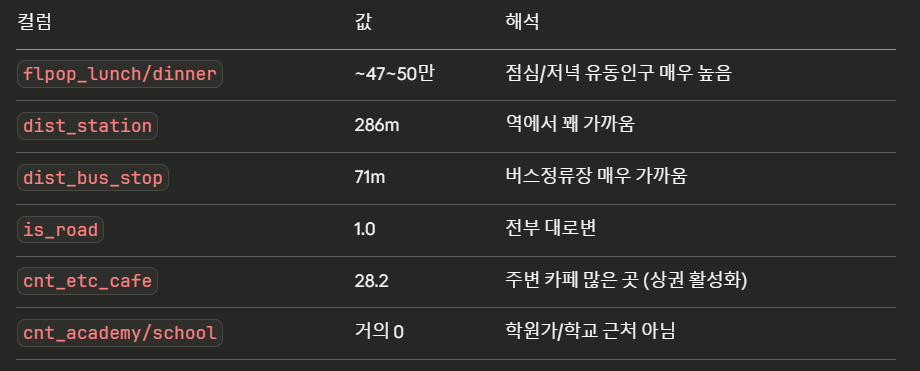

카페 입지에서 일반적으로 중요한 순서:
1. 유동인구: 카페는 지나가다 들어오는 업종. 사람이 많아야 매출 나옴
2. 접근성: 오기 편해야 재방문율 높아짐, 주변 시설타겟 고객층 확보
3. 경쟁 강도경쟁 많은 곳 = 오히려 상권 활성화된 곳 (ideal에서 cnt_etc_cafe 28개였음)

+ 유동인구 40% + 접근성 30% + 주변시설 20% + 경쟁강도 10%

In [84]:
# 1) 입지 특성 컬럼 정의
feature_cols = [
    "flpop_lunch", "flpop_dinner", "flpop_etc",
    "dist_station", "dist_bus_stop",
    "cnt_crosswalk", "is_road",
    "cnt_academy", "cnt_hospital", "cnt_school", "cnt_company",
    "cnt_banapresso", "cnt_high_cafe", "cnt_low_cafe", "cnt_etc_cafe"
]

# 2) 방향 정의
higher_better = [
    "flpop_lunch", "flpop_dinner", "flpop_etc",
    "cnt_crosswalk", "is_road",
    "cnt_academy", "cnt_hospital", "cnt_school", "cnt_company",
    "cnt_high_cafe", "cnt_low_cafe", "cnt_etc_cafe"
]
lower_better = ["dist_station", "dist_bus_stop", "cnt_banapresso"]

# 3) 가중치
weights = {
    "flpop_lunch": 0.15, "flpop_dinner": 0.15, "flpop_etc": 0.10,
    "dist_station": 0.10, "dist_bus_stop": 0.08,
    "cnt_crosswalk": 0.07, "is_road": 0.05,
    "cnt_academy": 0.05, "cnt_hospital": 0.05,
    "cnt_school": 0.05, "cnt_company": 0.05,
    "cnt_banapresso": 0.02, "cnt_high_cafe": 0.03,
    "cnt_low_cafe": 0.02, "cnt_etc_cafe": 0.03,
}

# 4) lower_better 반전 후 정규화
score_df = bana_df[feature_cols].copy()
for col in lower_better:
    score_df[col] = -score_df[col]

scaler = MinMaxScaler()
score_scaled = pd.DataFrame(
    scaler.fit_transform(score_df),
    columns=feature_cols,
    index=bana_df.index
)

# 5) 가중치 적용 → 최종 점수
bana_df["location_score"] = score_scaled.apply(
    lambda row: sum(row[col] * weights[col] for col in weights), axis=1
)

# 6) 검증 - success 그룹별 평균 점수
print(bana_df.groupby("success")["location_score"].mean())

# 7) 점수 순위
bana_df[["nm", "location_score", "success"]].sort_values("location_score", ascending=False)

success
0    0.343460
1    0.404263
Name: location_score, dtype: float64


,nm,location_score,success
26,바나프레소 강남역아라타워점,0.828385,0
45,바나프레소 신림역점,0.547578,0
4,바나프레소 선릉공원점,0.532973,1
0,바나프레소 테헤란로점,0.532725,1
50,바나프레소 그랑서울점,0.516871,0
43,바나프레소 서울대입구역점,0.492769,0
49,바나프레소 을지로3가역점,0.453274,0
57,바나프레소 동소문점,0.445601,0
29,바나프레소 서울성균관대점,0.440952,0
3,바나프레소 신논현역점,0.437987,1


# 6. 매물 점수화하기

In [85]:
listing_df = pd.read_csv("C:/vs_code_prj/brewmap/data/mj/listing.csv")
listing_df.head()

,listing_id,addr,lat,lng,business_type,transaction_type,sale_price,key_money,deposit,monthly_rent,maintenance_fee,size_m2,floor,flpop_type,trdar_cd,adstrd_cd
0,575115,서울특별시 강남구 논현동,37.519306,127.029262,사무실,월세,0,0,30000000,2000000,0,82.60,4층,T,3120190,11680531
1,703777,서울특별시 서초구 잠원동,37.511775,127.020540,카페/커피,월세,0,40000000,50000000,3000000,0,33.06,1층,T,3120185,11650540
2,701846,서울특별시 강남구 논현동,37.512658,127.021577,사무실,월세,0,0,35000000,3000000,0,49.59,2층,T,3120185,11680521
3,455221,서울특별시 강남구 논현동,37.509032,127.023453,한식/고기집,월세,0,220000000,80000000,5500000,1200000,264.50,2층,T,3130303,11680521
4,394623,서울특별시 강남구 논현동,37.515856,127.030844,가구/가전,월세,0,200000000,50000000,3100000,600000,165.00,1층,T,3120191,11680531
